In [ ]:
"""
Implementation of Parallelized Extreme Learning Machine (P-ELM)
Target: Online Data Classification & DevOps Anomaly Detection

Author: Amanda Taheri
Based on the research paper:
Title: Parallelized Extreme Learning Machine for Online Data Classification
https://doi.org/10.1007/s10489-022-03308-7
Copyright (c) 2026. All rights reserved.

"""

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# Adding the 'src' directory to the system path to import our modules
sys.path.append(os.path.abspath(os.path.join('..')))

# Importing the final Online Parallel ELM
from src.elm_online import OnlineParallelELM

print("Environment ready. Online Parallel ELM loaded.")


Environment ready. Online Parallel ELM loaded.


In [2]:
def generate_devops_stream_batch(n_samples=3000, n_features=10, noise_level=0.1):
    """
    Simulates a stream of monitoring data.
    The goal is to learn a specific non-linear boundary.
    """
    np.random.seed(None) # Ensure different data for each batch
    X = np.random.randn(n_samples, n_features)
    
    # Target rule: A combination of few features (Simulating an anomaly condition)
    # If sum of first 3 features > 1.2, it's an anomaly (1), else normal (0)
    y = (np.sum(X[:, :3], axis=1) + np.random.normal(0, noise_level, n_samples) > 1.2).astype(int)
    
    return X, y

print("Stream Simulator function created.")


Stream Simulator function created.


In [3]:
# Initialize the Model
# 10 features, 500 hidden neurons, using 4 CPU cores
online_model = OnlineParallelELM(input_size=10, hidden_size=500, n_workers=4)

history_acc = []

print("Starting Online Learning Stream...")
print("-" * 40)

for wave in range(1, 6):
    # 1. Get new batch of data
    X_batch, y_batch = generate_devops_stream_batch()
    
    # 2. Update the Knowledge Base (Weight Synthesis)
    # This calls the parallel workers and then the WeightSynthesizer.update_knowledge_base
    online_model.learn_batch(X_batch, y_batch)
    
    # 3. Evaluate the current state of knowledge on the current batch
    y_pred = (online_model.predict(X_batch) > 0.5).astype(int)
    acc = accuracy_score(y_batch, y_pred)
    history_acc.append(acc)
    
    print(f"Wave {wave} processed | Accuracy: {acc*100:.2f}% | KB Updates: {online_model.synthesizer.n_updates}")

print("-" * 40)
print("Online Training Complete.")


Starting Online Learning Stream...
----------------------------------------
Wave 1 processed | Accuracy: 93.60% | KB Updates: 1
Wave 2 processed | Accuracy: 93.13% | KB Updates: 2
Wave 3 processed | Accuracy: 93.07% | KB Updates: 3
Wave 4 processed | Accuracy: 93.20% | KB Updates: 4
Wave 5 processed | Accuracy: 92.97% | KB Updates: 5
----------------------------------------
Online Training Complete.


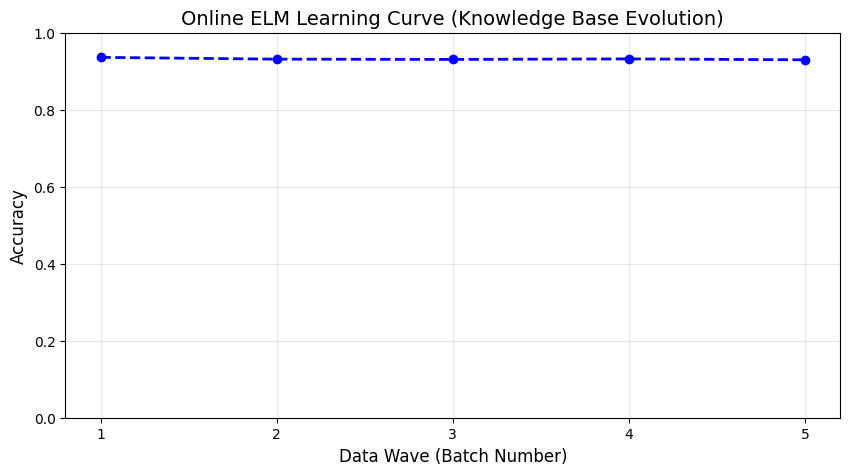

Final Wave Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2271
           1       0.89      0.81      0.85       729

    accuracy                           0.93      3000
   macro avg       0.92      0.89      0.90      3000
weighted avg       0.93      0.93      0.93      3000



In [4]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), history_acc, marker='o', linestyle='--', color='b', linewidth=2)
plt.title('Online ELM Learning Curve (Knowledge Base Evolution)', fontsize=14)
plt.xlabel('Data Wave (Batch Number)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])
plt.show()

# Final Detailed Report on the last batch
print("Final Wave Classification Report:")
print(classification_report(y_batch, y_pred))
